In [1]:
using LinearAlgebra
using Interpolations
using Optim
using Plots
using NBInclude

In [4]:
@nbinclude("stationary_dist.ipynb");

In [45]:
# Structural Parameters
α=.3                #capital share
β=.9               #time discount factor
γ=1.                #inverse of EIS
δ=.02               #capital depreciation rate
a_min=0.0           #borrowing constraint
a_max=200.0         #maximum asset
a_grid_size=201;    #number of points on the grid for savings

In [48]:
# Idiosyncratic income shocks
nz=2                                       #number of states   
jfp=0.4                                    #job finding proba 
jlp=0.2                                    #job loss proba
Q_z=[[1.0 - jfp; jfp] [jlp; 1.0 - jlp]]    #transiton matrix
z_low=.5                                   #labor income for z_low
z_high=2.                                 #labor income for z_high
z_grid=[z_low;z_high]                      #grid for income shocks
Lbar=dot(z_grid,get_stationary_dist(Q_z))  #normalizing constant
z_grid=z_grid./Lbar                        #normalized income shocks gris
z_grid_reshaped=repeat(z_grid,outer=[1,a_grid_size])
Lbar=1.;

In [33]:
# Assets grids
a_grid=collect(range(a_min^(0.25),stop=a_max^(0.25),length=a_grid_size)).^4
a_grid_reshaped=transpose(repeat(a_grid,outer=[1,nz]));
# Shift to positive, apply power, shift back (when negative assets are allowed)
#shift = abs(a_min) + 0.1
#a_grid = collect(range((a_min + shift)^(0.25),stop=(a_max + shift)^(0.25),length=a_grid_size)).^4 .- shift
#a_grid_reshaped = transpose(repeat(a_grid, outer=[1, nz]));

In [40]:
# Store some objects
para=(α=α,β=β,γ=γ,δ=δ,Lbar=Lbar,
a_grid_reshaped=a_grid_reshaped,z_grid=z_grid,Q_z=Q_z);

In [11]:
# Functions to compute the net interest rate and wage
function r_(K,Lbar,α,δ)
    return α*(K/Lbar)^(α-1)-δ
end

function W_(r,K,Lbar,α,δ)
    return (1-α)*(α/(r+δ))^(α/(1-α)) 
end;

In [12]:
"""
Define a transition matrix.
The state for an individual is determined by 
his current level of asset + current idiosyncratic shock
"""
function make_trans_mat(G,a_grid_reshaped,Q_z)

    # Intilization
    nz,a_grid_size=size(G)

    #To hold both idiosyncratic state + asset level
    T = zeros(nz*a_grid_size, nz*a_grid_size)
    # Loop over savings:
    for a_i = 1:a_grid_size
        # Loop over current idiosyncratic level:
        for j = 1:nz
            #Find the row index such that the policy function generates
            #the savings next period:
            ind = searchsortedfirst(G[j, :], a_grid_reshaped[j,a_i])
            #Control for boundary cases
            ind = min(max(ind,2), a_grid_size)
            #Project on grid using Young (2010) method. First calculate weigths
            pp = (a_grid_reshaped[j, a_i] - G[j, ind-1]) / (G[j, ind] - G[j, ind-1])
            pp = min(max(pp, 0.0), 1.0)
            sj = (j-1)*a_grid_size
            # Loop over next period's idiosyncratic level
            for k = 1:nz
                sk = (k-1)*a_grid_size
                # weight on the grid point above
                T[sk+ind,sj+a_i] = pp * Q_z[k,j]
                # weight on the grid point above
                T[sk+ind-1,sj+a_i] = (1.0-pp) * Q_z[k,j]
            end
        end
    end
    return T
end;

In [15]:
# Solves the households' problem with EGM
function inner_loop(r,W,para,
                     max_iter=10000,
                     tol=1e-10,
                     success_flag=0,
                     verbose=false
                     )
    # Unpack
    a_grid_reshaped=para.a_grid_reshaped
    z_grid=para.z_grid
    Q_z=para.Q_z
    β=para.β
    γ=para.γ
    
    # Initialization
    a_old = copy(a_grid_reshaped)
    a_new = copy(a_grid_reshaped)
    c_new = copy(a_grid_reshaped)
    g_old = [x -> 0.9 * x for i=1:nz]
    g_new = [x -> 0.9 * x for i=1:nz]
    iter=0

    # Gross interest rate
    R=(1+r)
    # Borrowing limit
    a_min = a_grid_reshaped[1, 1]

    for it = 1:max_iter
        
        iter = it

        #1. Next period's consumption, conditional on next period's income
        a_prime = vcat([g_old[i].(a_grid_reshaped[i, :])' for i in 1:length(g_old)]...)
        c_prime = R.*a_grid_reshaped .+ W*z_grid .- a_prime
        #2. Next period marginal utility of consumption
        up_cp=c_prime.^(-γ)
        #3. Expectation with respect to changes in idiosyncratic productivity
        E_up_cp = transpose(Q_z)*up_cp
        #4. Marginal utility of consumption = R' *  beta*Eupcp
        up_c = (R*β).*E_up_cp
        #5. Invert marginal utility of consumption to get consumption
        c=up_c.^(-1.0/γ)
        #6. The budget constraint implies the beginning-of-period asset:
        #aR = (a' + c - y)
        a_new = (a_grid_reshaped .+ c .- W.*z_grid)./R
        # permutations to sort data in increasing order:
        p = [sortperm(a_new[i, :]) for i in 1:size(a_new,1)]
        #7. Coleman operator
        #Kg=[LinearInterpolation(a_new[i, p[i]], a_grid_reshaped[i,p[i]], extrapolation_bc=Line()) for i in 1:nz]
        Kg = [let interp = LinearInterpolation(a_new[i, p[i]], a_grid_reshaped[i, p[i]], extrapolation_bc=Line())
                x -> max.(a_min, interp.(x))
                end for i in 1:nz]
        
        if mod(iter,50)==0
            if verbose==true
                println("$(maximum(abs.(a_new - a_old)))")
            end
        end

        # Check for convergence of assets grids:
        if maximum(abs.(a_new - a_old))  < tol
            if verbose==true
                println("Convergence reached after $(it) iterations")
            end
            success_flag = 1
            break
        #Otherwise, update policy functions a'=g(a,e)
        else
            a_old = copy(a_new)   #Policy function on grid points
            g_old = Kg            #Policy function interpolated
        end

    end

    return a_new ,success_flag,iter 
end;

In [14]:
function outer_loop(K,para)
    
    #Unpack
    Lbar=para.Lbar
    α=para.α
    δ=para.δ
    a_grid_reshaped=para.a_grid_reshaped
    Q_z=para.Q_z

    r=r_(K,Lbar,α,δ); W=W_(r,K,Lbar,α,δ)
    aa,_,_ =inner_loop(r,W,para)                    #solve household problem with EGM
    Pi=make_trans_mat(aa,a_grid_reshaped,Q_z)       #generate transition matrix on the state
    Psi=get_stationary_dist(Pi)                     #stationary distribution
    Kp=dot(vec(a_grid_reshaped'),Psi)               #implied level of aggregate capital

    return 0.5*(Kp - K)^2
end;

In [49]:
oo=optimize(K ->outer_loop(K,para), 10, 100, Brent());
K_star = oo.minimizer;
println("Steady-state value of capital K* = $(K_star)")

Steady-state value of capital K* = 17.478460963374143


In [50]:
# Other steady state values
r_star=r_(K_star,Lbar,α,δ); W_star=W_(r_star,K_star,Lbar,α,δ)
Y_star=K_star^α
a_star,_,_ =inner_loop(r_star,W_star,para)  
Pi=make_trans_mat(a_star,a_grid_reshaped,Q_z)       
Psi=get_stationary_dist(Pi)  
Psi_star=reshape(Psi,a_grid_size,nz)
p=[sortperm(a_star[i, :]) for i in 1:size(a_star,1)]
a_min=a_grid_reshaped[1, 1]
a_policy = [let interp = LinearInterpolation(a_star[i, p[i]], a_grid_reshaped[i, p[i]], extrapolation_bc=Line())
            x -> max.(a_min, interp.(x))
            end for i in 1:nz]
# Evaluate policy on the original grid
a_prime=vcat([a_policy[i].(a_grid)' for i in 1:nz]...);

In [22]:
# how to use a_policy
a_policy[1](a_grid);
a_policy[1](20)

18.571015532519564

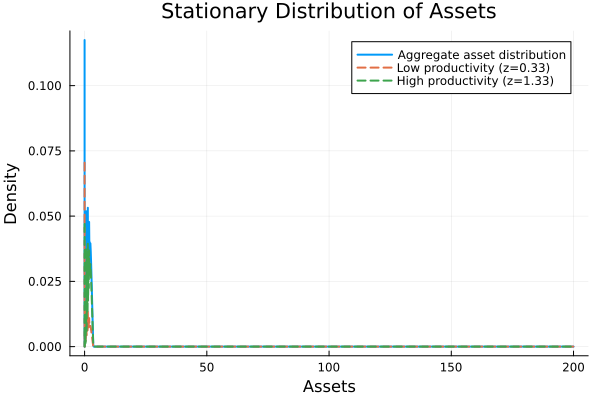

In [51]:
# Wealth distribution
asset_dist = sum(Psi_star, dims=2)[:]
# Create the combined plot
plot(a_grid, asset_dist,
     label="Aggregate asset distribution",
     xlabel="Assets",
     ylabel="Density",
     title="Stationary Distribution of Assets",
     linewidth=2,
     legend=:topright)
plot!(a_grid, Psi_star[:, 1],
      label="Low productivity (z=$(round(z_grid[1], digits=2)))",
      linewidth=2,
      linestyle=:dash)
plot!(a_grid, Psi_star[:, 2],
      label="High productivity (z=$(round(z_grid[2], digits=2)))",
      linewidth=2,
      linestyle=:dash)

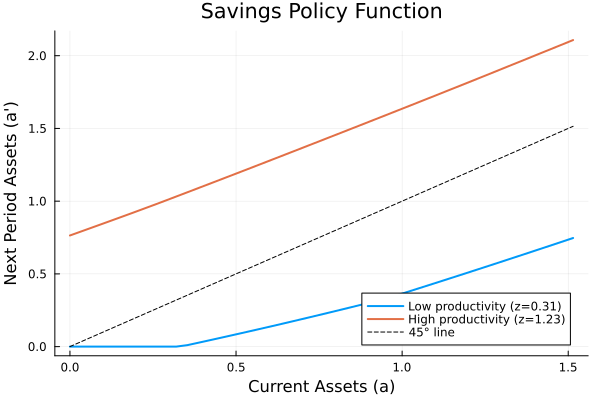

In [44]:
# Savings policy function
plot(a_grid[1:60],a_prime[1,1:60],
     label="Low productivity (z=$(round(z_grid[1], digits=2)))",
     xlabel="Current Assets (a)",
     ylabel="Next Period Assets (a')",
     title="Savings Policy Function",
     linewidth=2,
     legend=:bottomright)
plot!(a_grid[1:60], a_prime[2,1:60], 
      label="High productivity (z=$(round(z_grid[2], digits=2)))",
      linewidth=2)
plot!(a_grid[1:60], a_grid[1:60],
      label="45° line",
      linestyle=:dash,
      color=:black,
      linewidth=1)